In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler,MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score ,f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings("ignore")

In [12]:
df=pd.read_csv(r"C:\Users\SCA_11\Downloads\Churn_Modelling (4).csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [14]:
df.isna().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
Numerical_Columns=df.select_dtypes(include=['int64','float64']).columns
Numerical_Columns

Index(['RowNumber', 'CustomerId', 'CreditScore', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='object')

In [17]:
cont_col=['Age','CreditScore','Balance','EstimatedSalary']

for col in cont_col:
    print(f"\n{col} Exploration")
    print(df[col].describe())
    print('-' * 60)


Age Exploration
count    10000.000000
mean        38.921800
std         10.487806
min         18.000000
25%         32.000000
50%         37.000000
75%         44.000000
max         92.000000
Name: Age, dtype: float64
------------------------------------------------------------

CreditScore Exploration
count    10000.000000
mean       650.528800
std         96.653299
min        350.000000
25%        584.000000
50%        652.000000
75%        718.000000
max        850.000000
Name: CreditScore, dtype: float64
------------------------------------------------------------

Balance Exploration
count     10000.000000
mean      76485.889288
std       62397.405202
min           0.000000
25%           0.000000
50%       97198.540000
75%      127644.240000
max      250898.090000
Name: Balance, dtype: float64
------------------------------------------------------------

EstimatedSalary Exploration
count     10000.000000
mean     100090.239881
std       57510.492818
min          11.580000
25%    

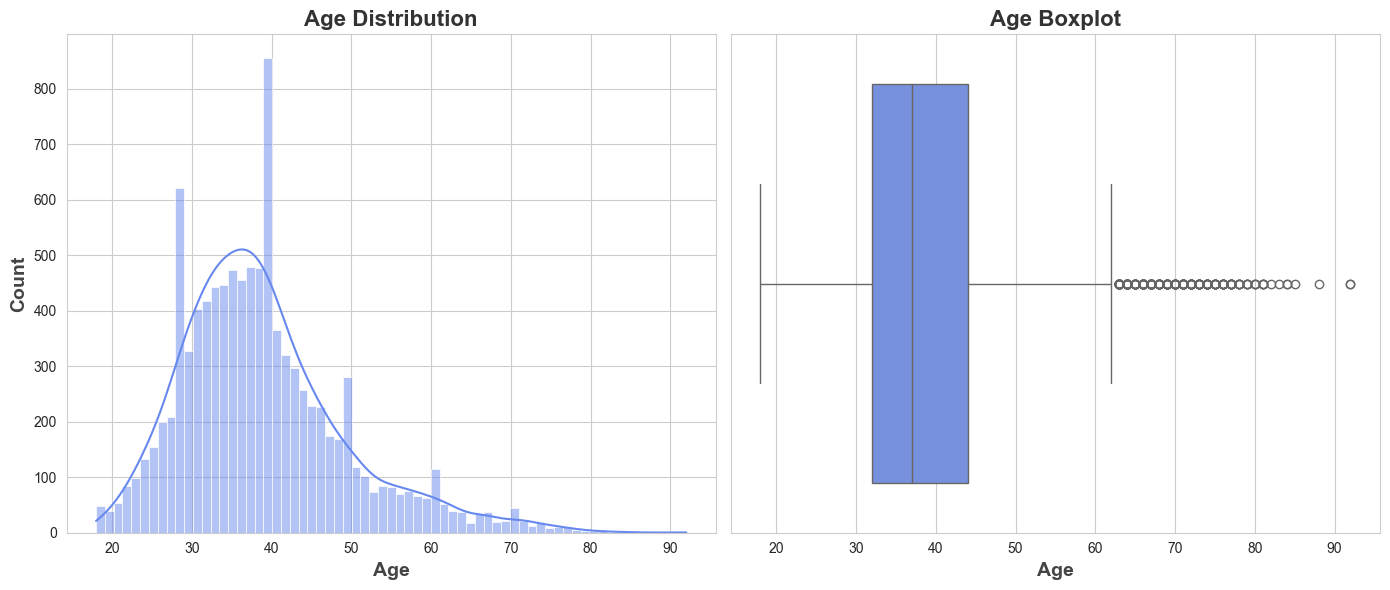

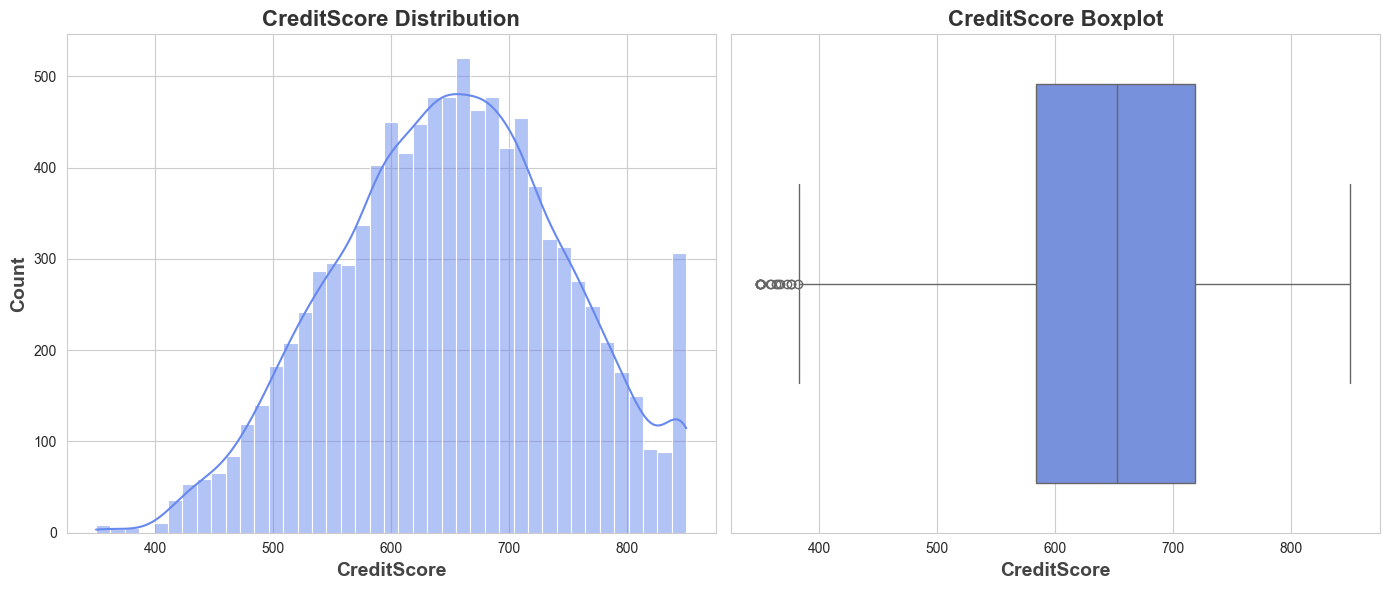

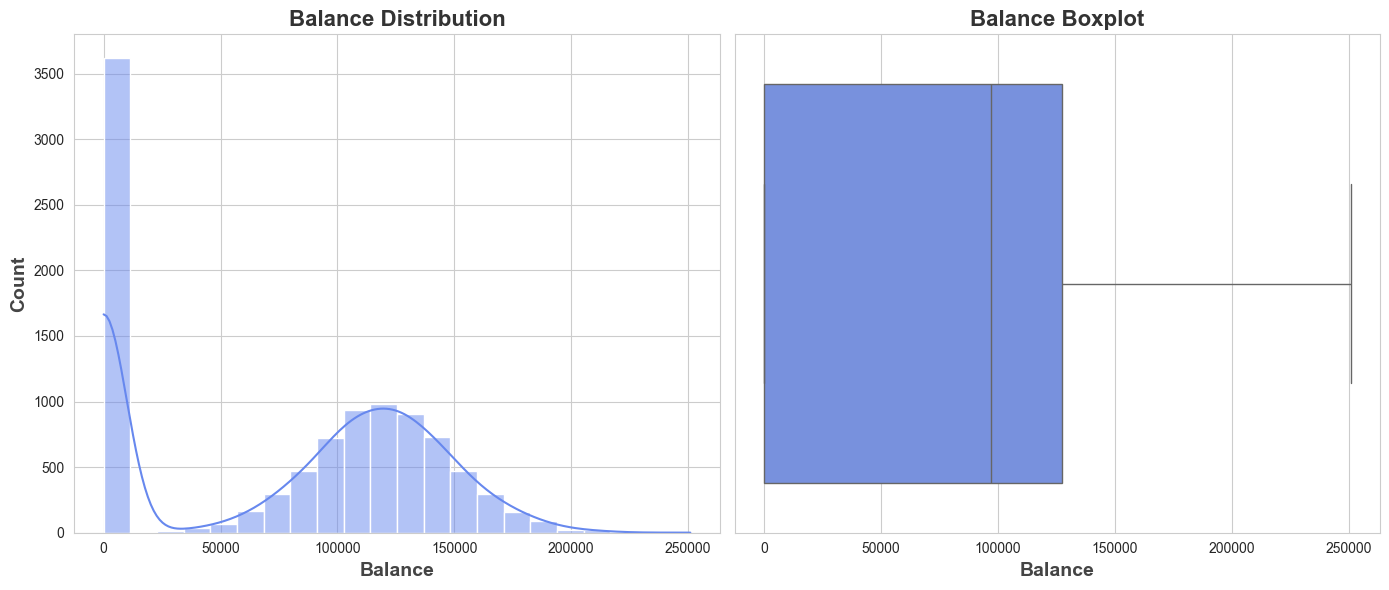

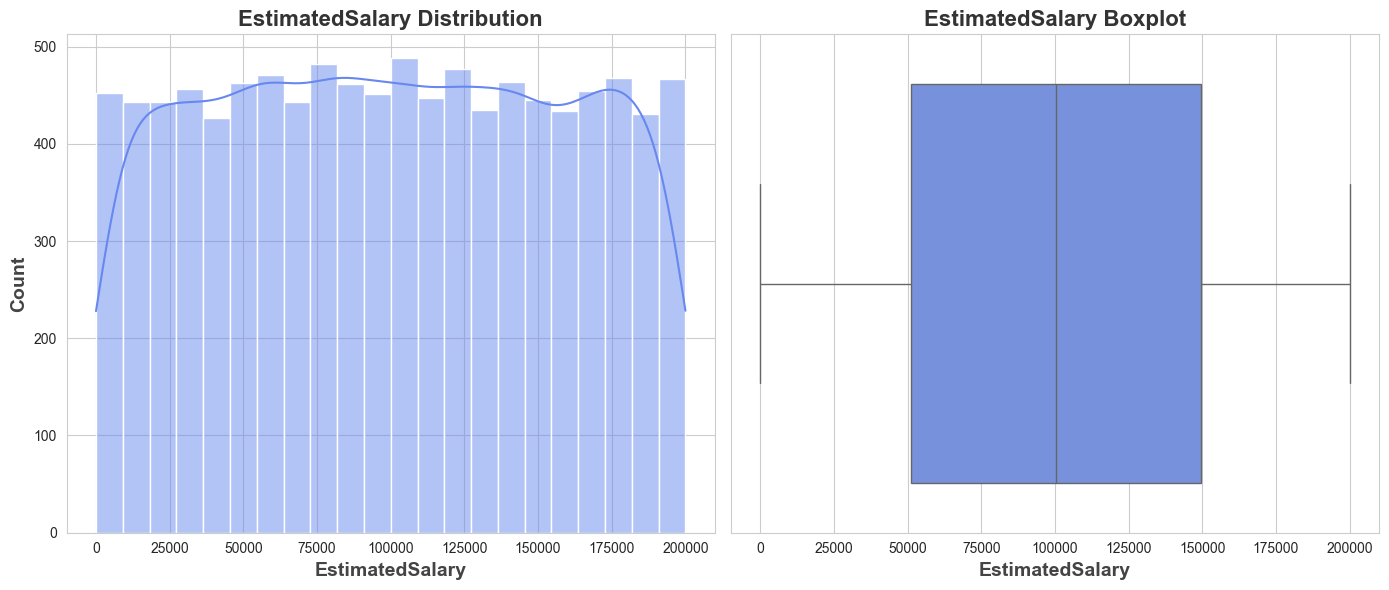

In [18]:
cont_col = ['Age', 'CreditScore', 'Balance', 'EstimatedSalary']

sns.set_style("whitegrid")
sns.set_palette("coolwarm")

for col in cont_col:
    plt.figure(figsize=(14, 6))

   
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} Distribution", fontsize=16, fontweight='bold', color='#333')
    plt.xlabel(col, fontsize=14, fontweight='bold', color='#444')
    plt.ylabel("Count", fontsize=14, fontweight='bold', color='#444')

   
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col])
    plt.title(f"{col} Boxplot", fontsize=16, fontweight='bold', color='#333')
    plt.xlabel(col, fontsize=14, fontweight='bold', color='#444')

    plt.tight_layout()
    plt.show()

In [19]:
discrete_Columns=df.select_dtypes(include=['int64','object']).columns
discrete_Columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'Exited'],
      dtype='object')

In [20]:
cat_col = ['Geography', 'Tenure', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'Exited']

for col in cat_col:
    print(df[col].value_counts())
    print('-'*70)

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64
----------------------------------------------------------------------
Tenure
2     1048
1     1035
7     1028
8     1025
5     1012
3     1009
4      989
9      984
6      967
10     490
0      413
Name: count, dtype: int64
----------------------------------------------------------------------
NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64
----------------------------------------------------------------------
HasCrCard
1    7055
0    2945
Name: count, dtype: int64
----------------------------------------------------------------------
IsActiveMember
1    5151
0    4849
Name: count, dtype: int64
----------------------------------------------------------------------
Exited
0    7963
1    2037
Name: count, dtype: int64
----------------------------------------------------------------------


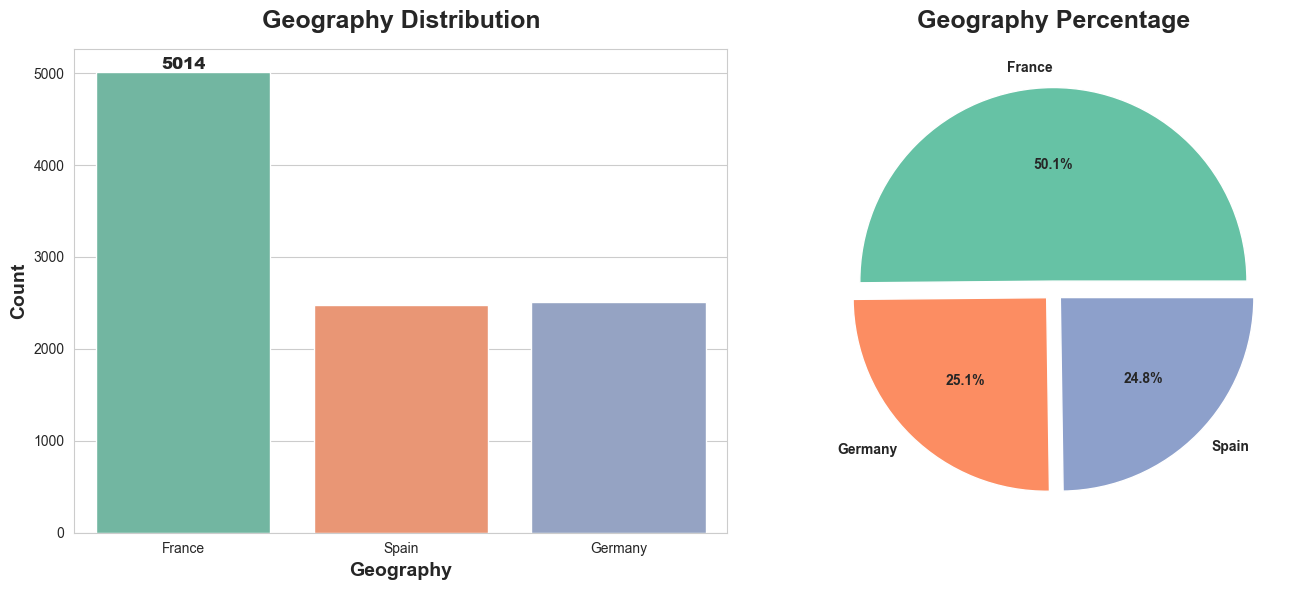

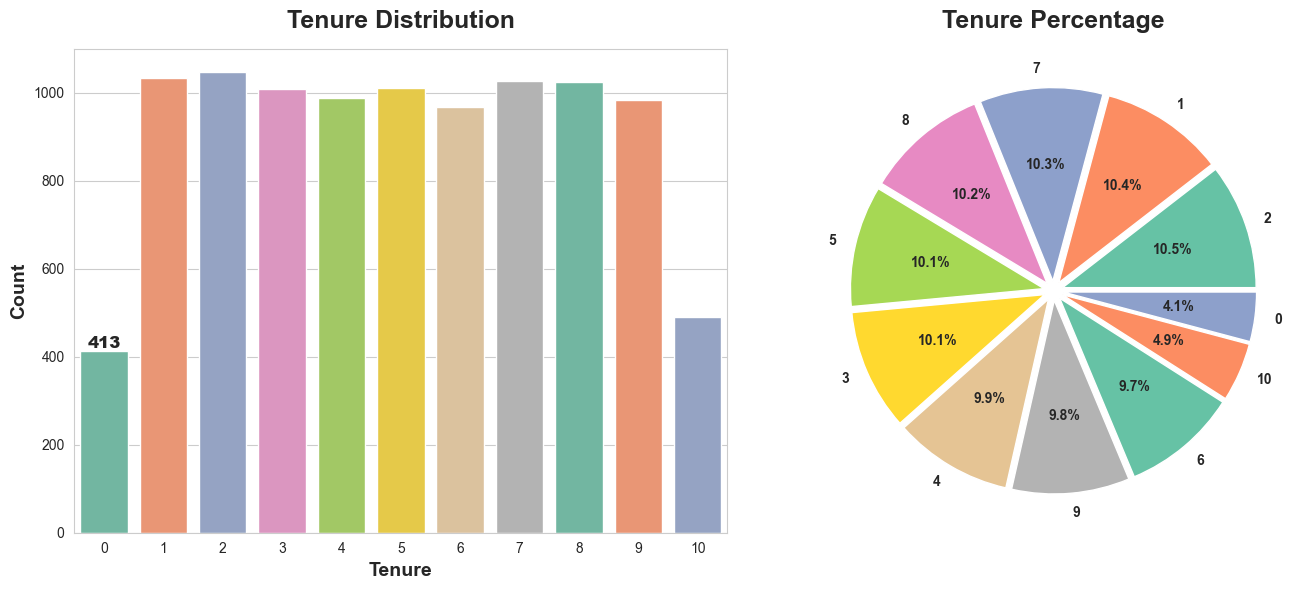

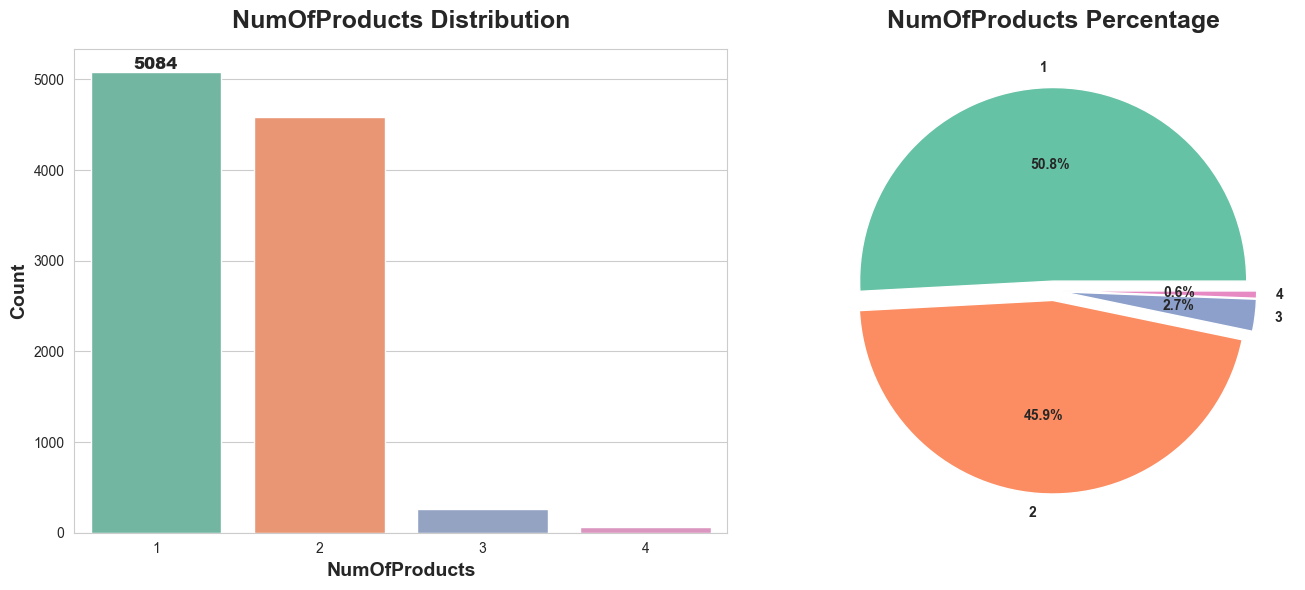

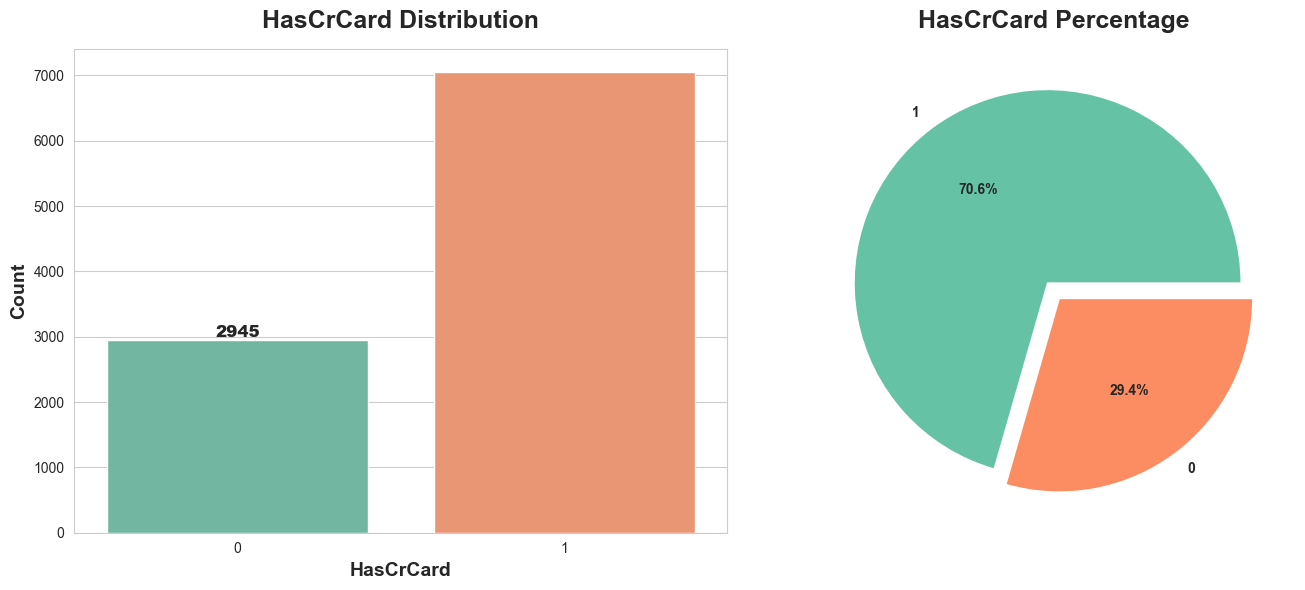

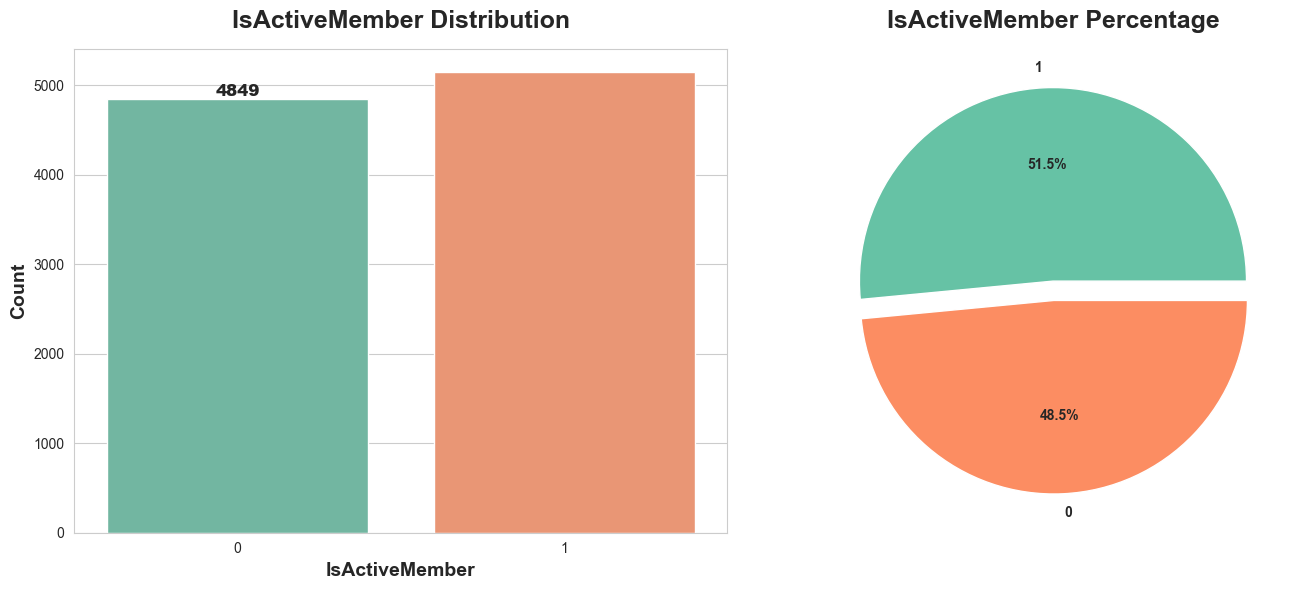

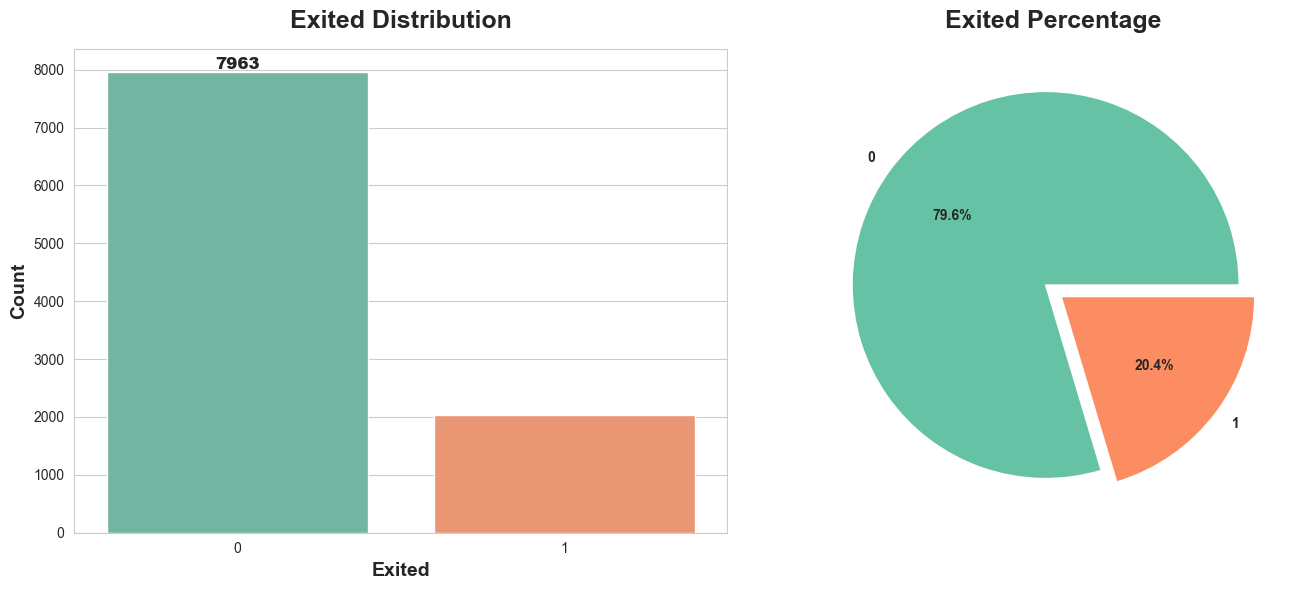

In [21]:
cat_col = ['Geography', 'Tenure', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'Exited']

for col in cat_col:
    count = df[col].value_counts()
    plt.figure(figsize=(14,6))
    plt.subplot(1, 2, 1)
    ax = sns.countplot(data=df, x=col, palette="Set2")
    ax.bar_label(ax.containers[0], fontweight="black", size=12)
    plt.title(f"{col} Distribution", fontweight="bold", size=18, pad=15)
    plt.xlabel(col, fontsize=14, fontweight="bold")
    plt.ylabel("Count", fontsize=14, fontweight="bold")


    plt.subplot(1, 2, 2)
    plt.pie(count.values,labels=count.index,autopct="%1.1f%%",colors=sns.color_palette("Set2"),textprops={"fontweight": "bold"},explode=[0.05]*len(count))
    plt.title(f"{col} Percentage", fontweight="bold", size=18, pad=15)
    plt.tight_layout()
    plt.show()


In [22]:
cont_col = ['Age', 'CreditScore', 'Balance', 'EstimatedSalary']

df.groupby('Exited')[cont_col].median().reset_index().T

,0,1
Exited,0.00,1.00
Age,36.00,45.00
CreditScore,653.00,646.00
Balance,92072.68,109349.29
EstimatedSalary,99645.04,102460.84


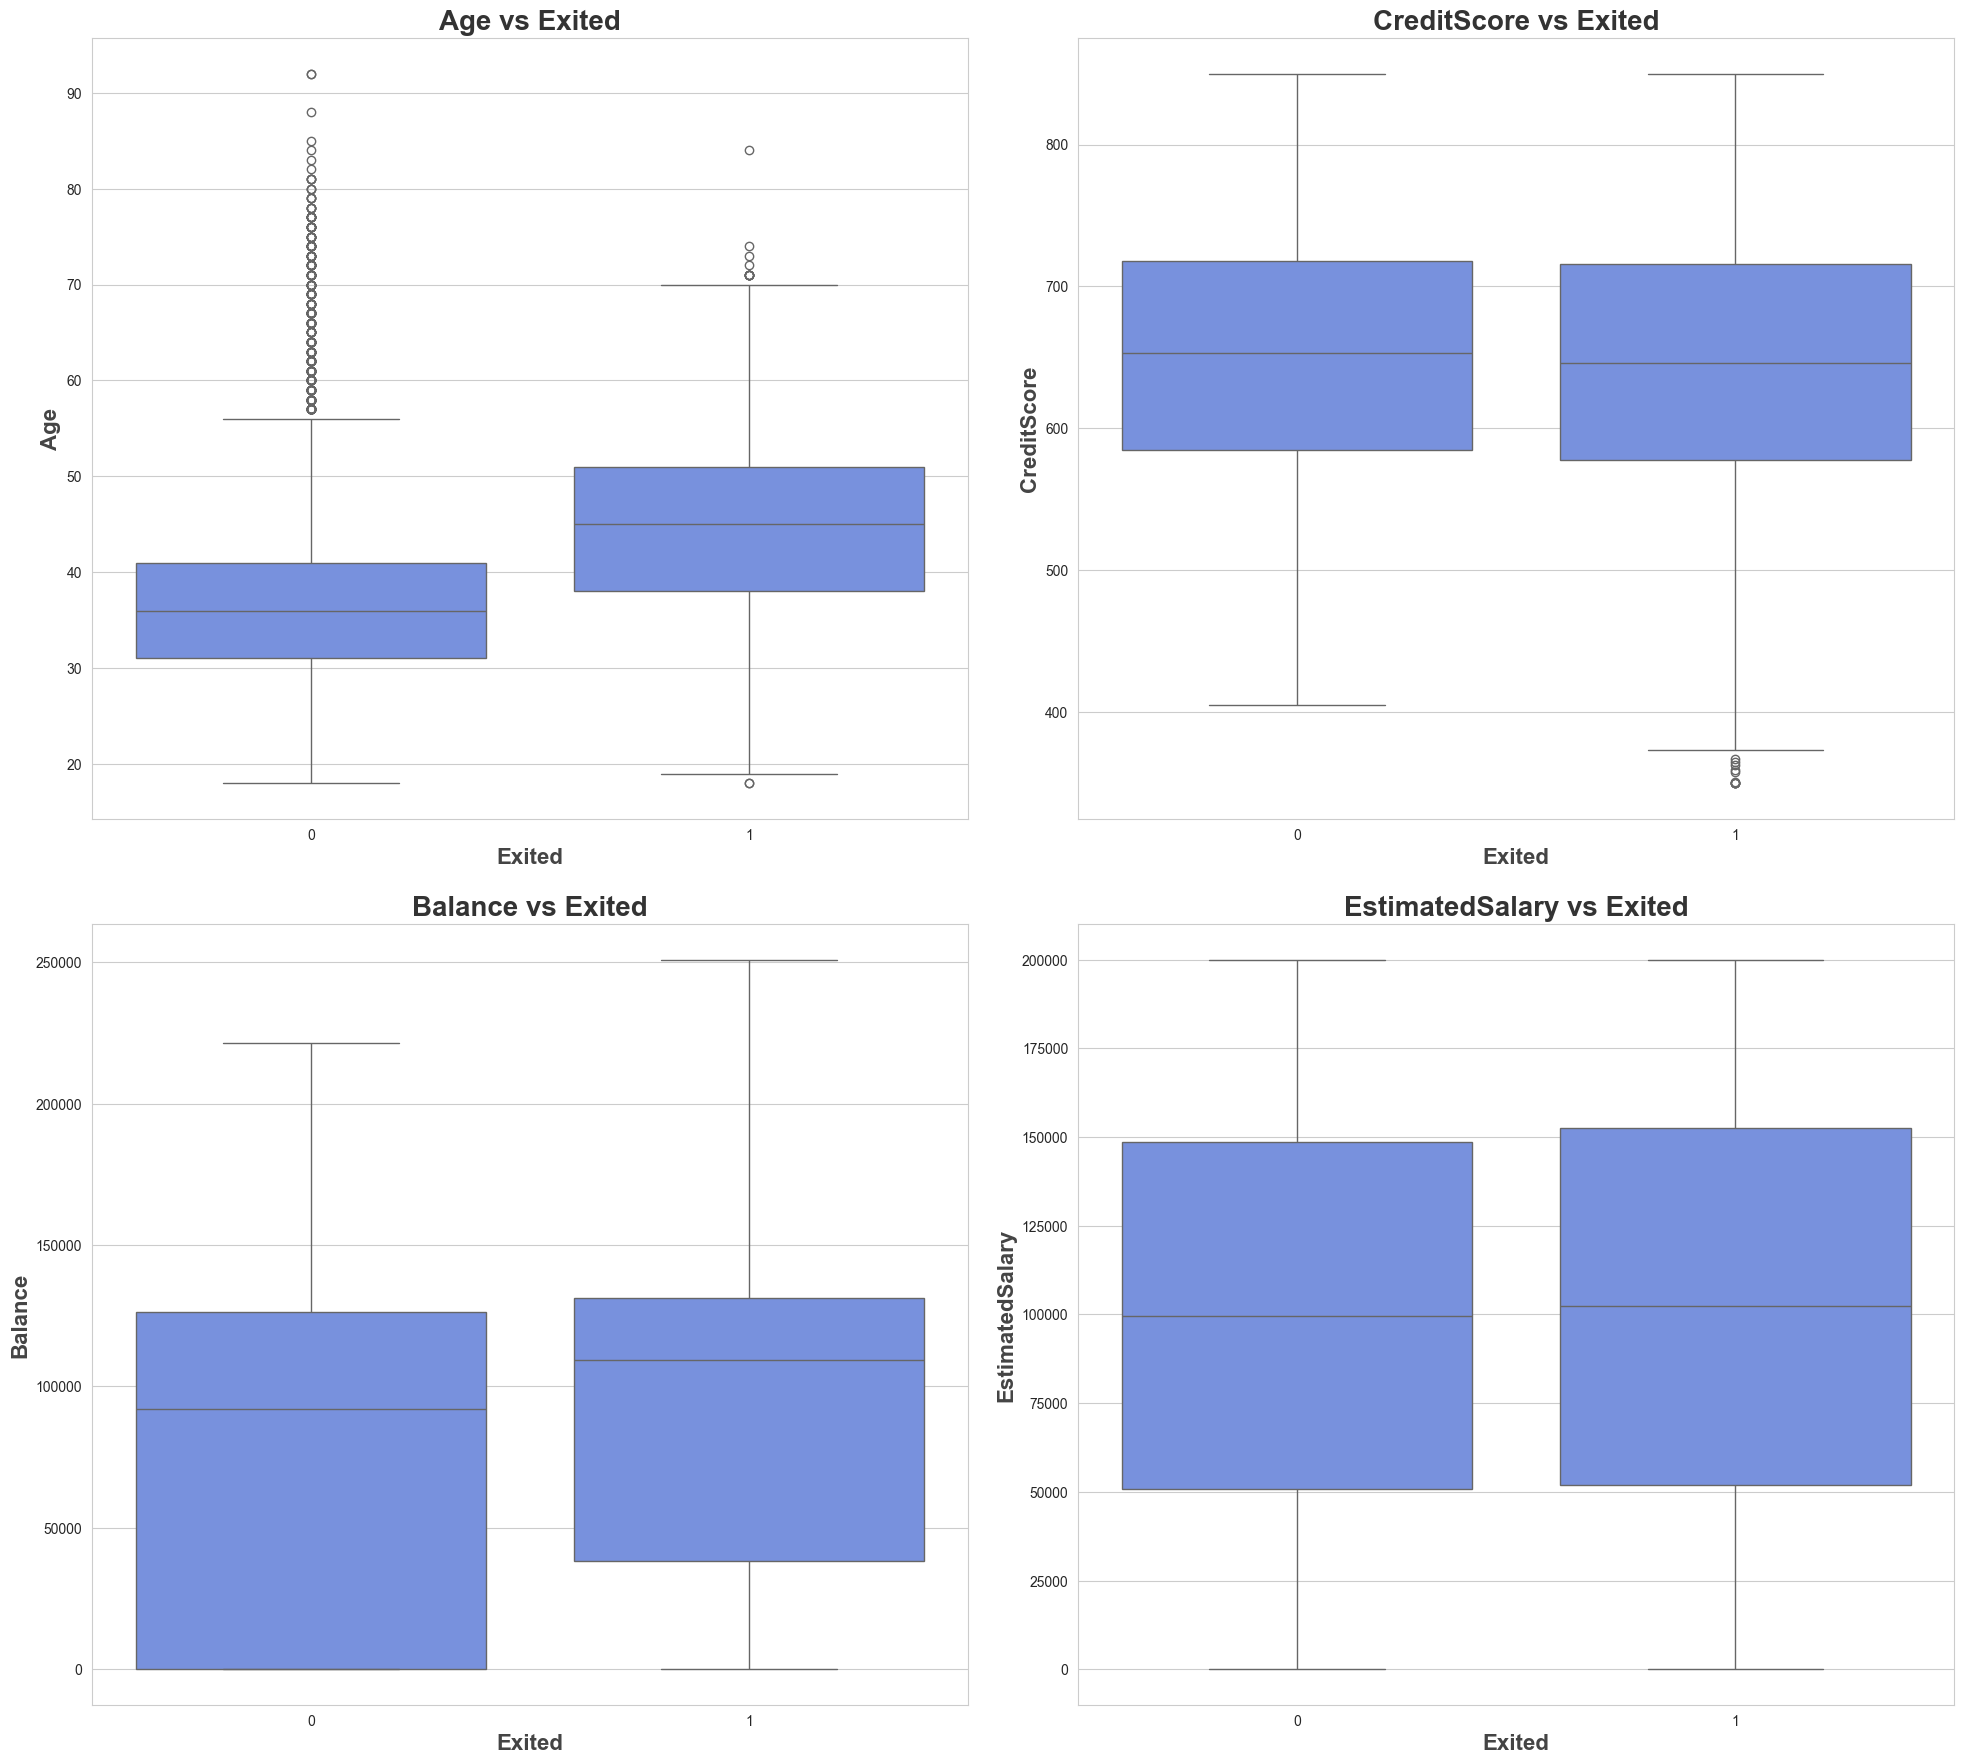

In [23]:
cont_col = ['Age', 'CreditScore', 'Balance', 'EstimatedSalary']

sns.set_style("whitegrid")
sns.set_palette("coolwarm")

plt.figure(figsize=(20, 18))

for i, col in enumerate(cont_col, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='Exited', y=col, data=df)
    plt.title(f"{col} vs Exited", fontsize=20, fontweight='bold', color='#333')
    plt.xlabel("Exited", fontsize=16, fontweight='bold', color='#444')
    plt.ylabel(col, fontsize=16, fontweight='bold', color='#444')

plt.tight_layout(pad=2.0)
plt.show()
    

In [24]:
cat_col = ['Geography', 'Tenure', 'NumOfProducts', 'HasCrCard', 'IsActiveMember']

for col in cat_col:
    result = df.groupby(col)['Exited'].mean().sort_values(ascending=False)
    print(f"\n{col} vs Exited:")
    print(result)
    print('-'*50)


Geography vs Exited:
Geography
Germany    0.324432
Spain      0.166734
France     0.161548
Name: Exited, dtype: float64
--------------------------------------------------

Tenure vs Exited:
Tenure
0     0.230024
1     0.224155
9     0.216463
3     0.211100
5     0.206522
10    0.206122
4     0.205258
6     0.202689
8     0.192195
2     0.191794
7     0.172179
Name: Exited, dtype: float64
--------------------------------------------------

NumOfProducts vs Exited:
NumOfProducts
4    1.000000
3    0.827068
1    0.277144
2    0.075817
Name: Exited, dtype: float64
--------------------------------------------------

HasCrCard vs Exited:
HasCrCard
0    0.208149
1    0.201843
Name: Exited, dtype: float64
--------------------------------------------------

IsActiveMember vs Exited:
IsActiveMember
0    0.268509
1    0.142691
Name: Exited, dtype: float64
--------------------------------------------------


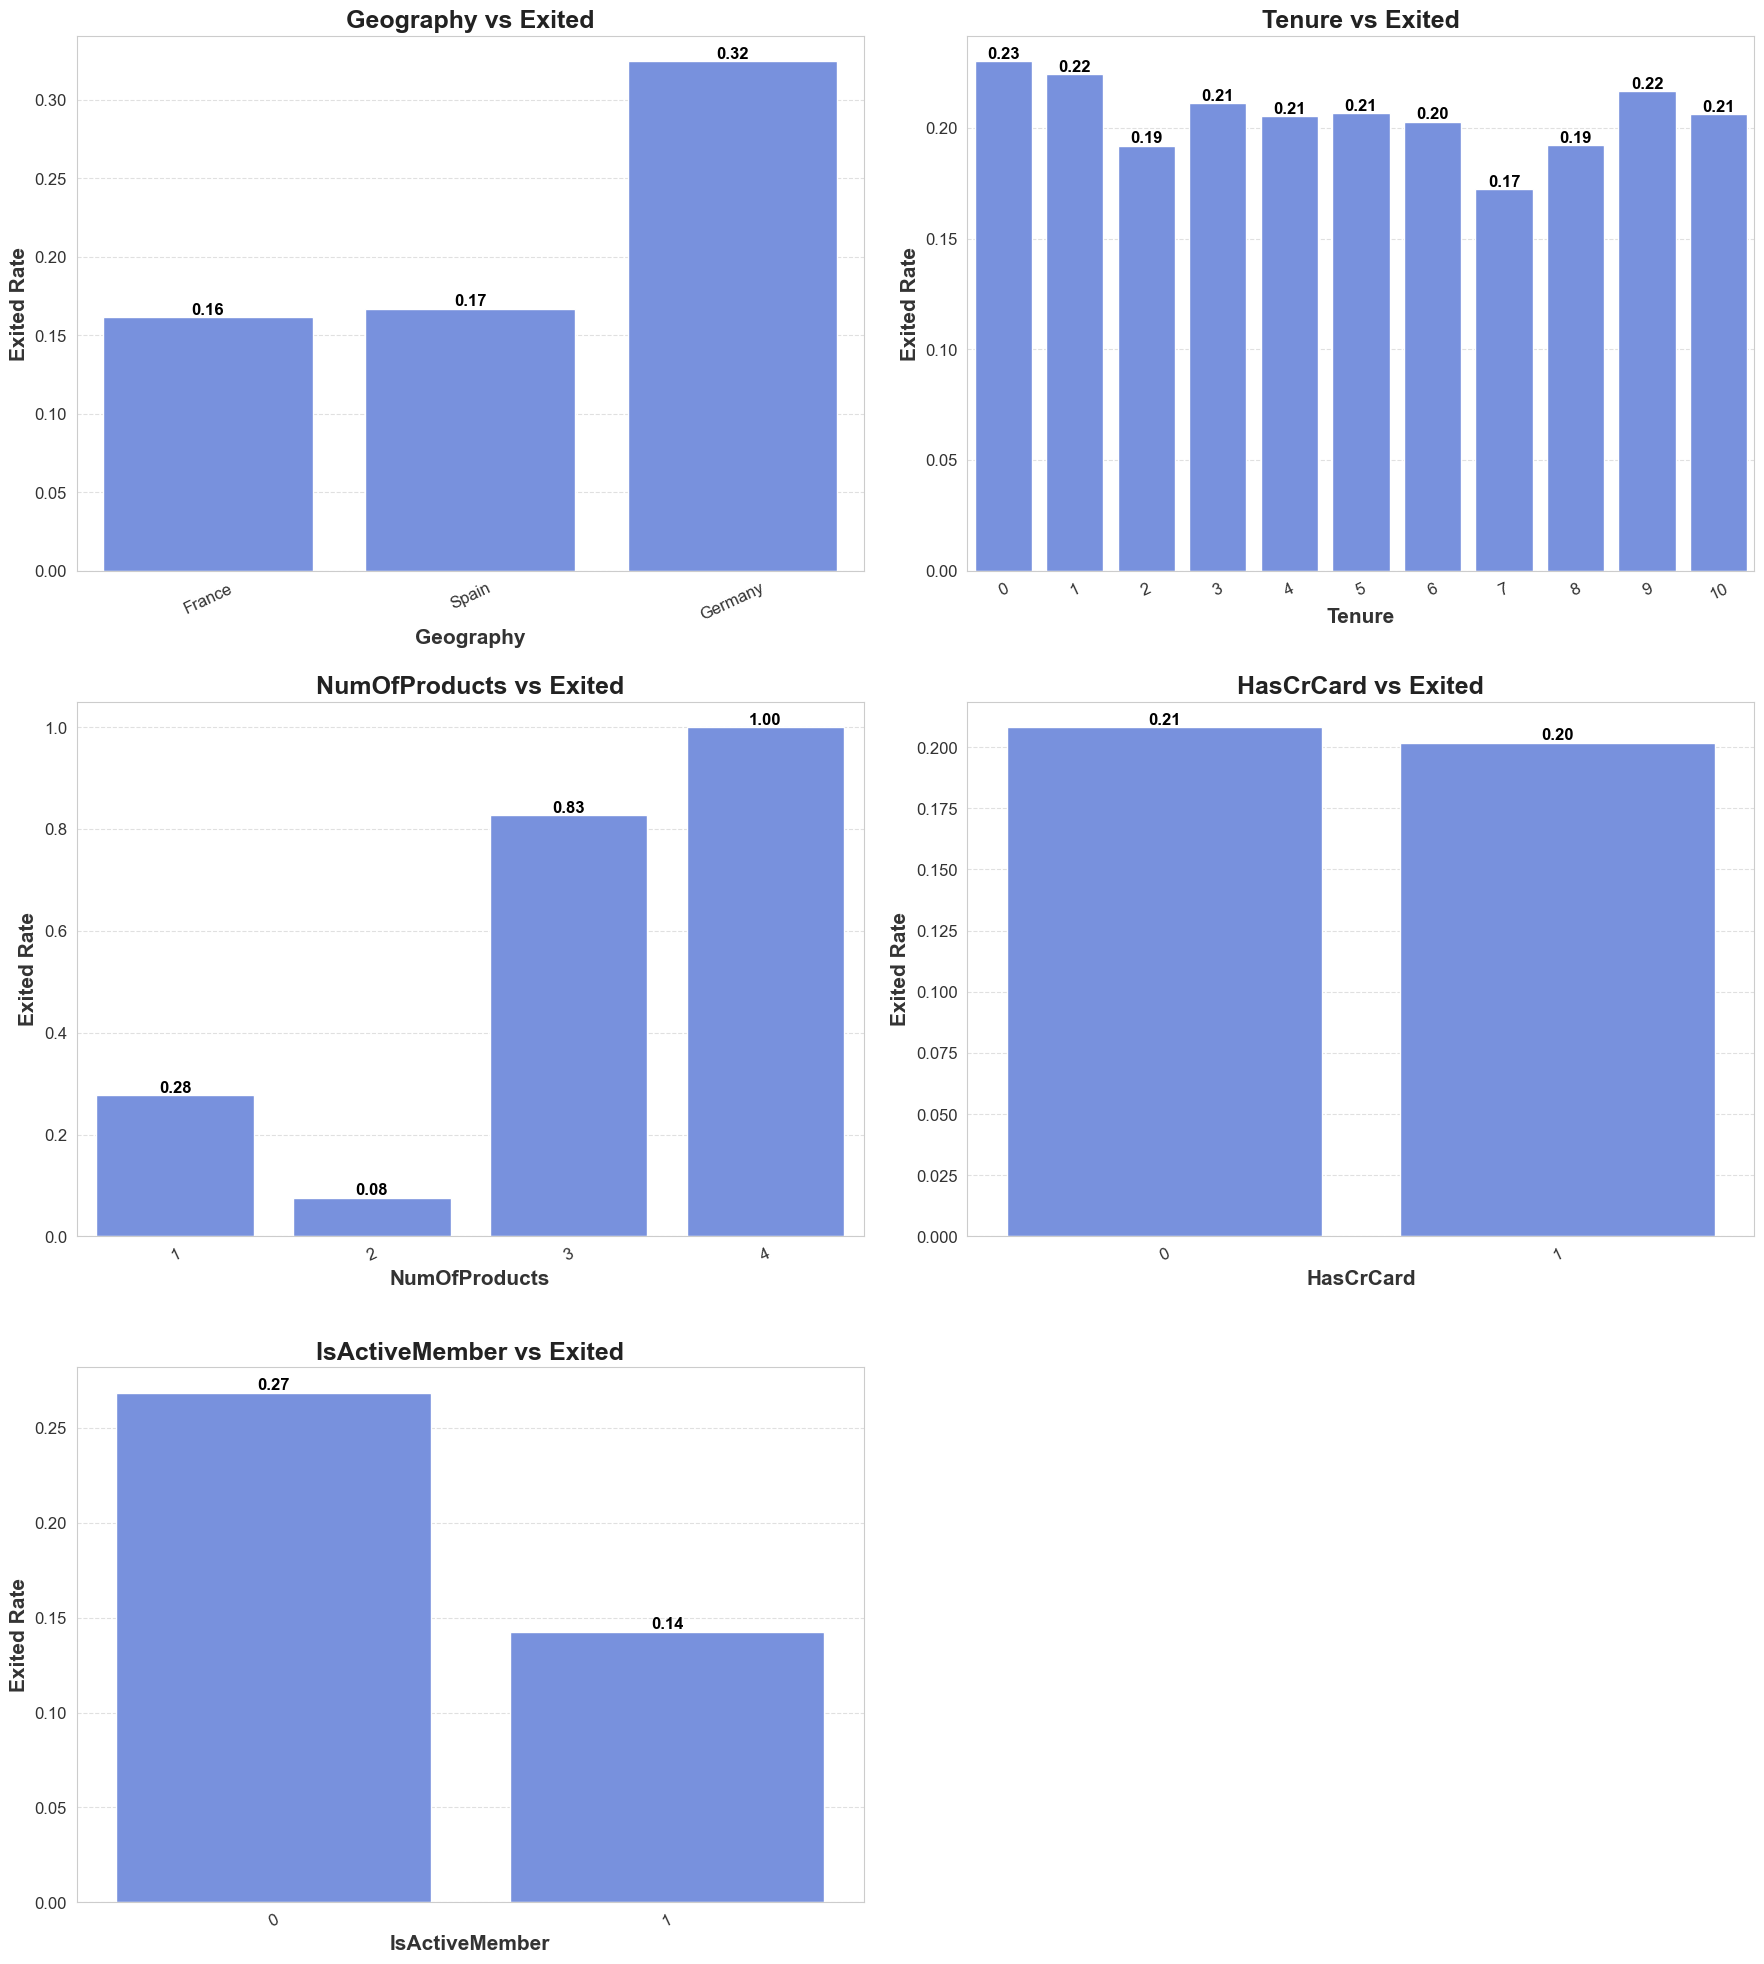

In [25]:
sns.set_style("whitegrid")
sns.set_palette("coolwarm")

plt.figure(figsize=(18, 20))

for i, col in enumerate(cat_col, 1):
    
    plt.subplot(3, 2, i)
    bar=sns.barplot(x=col, y='Exited', data=df, estimator='mean', errorbar=None)
    plt.title(f"{col} vs Exited", fontsize=18, fontweight='bold', color='#222')
    plt.xlabel(col, fontsize=15, fontweight='bold', color='#333')
    plt.ylabel("Exited Rate", fontsize=15, fontweight='bold', color='#333')
    plt.xticks(rotation=25, fontsize=12, color='#333')
    plt.yticks(fontsize=12, color='#333')
    plt.grid(axis='y', linestyle='--', alpha=0.6)


    for p in bar.patches:
        bar.annotate(
            f"{p.get_height():.2f}",
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center', va='bottom',
            fontsize=12, color='black', fontweight='bold'
        )

plt.tight_layout(pad=2.0)
plt.show()


In [26]:
new_df=df.drop(['RowNumber','CustomerId','Surname'],axis=1)
new_df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [27]:
X=new_df.drop('Exited',axis=1)
y=new_df['Exited']

In [28]:
X = pd.get_dummies(X, columns=['Geography', 'Gender'], drop_first=False)

In [29]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)

In [30]:
X_train.shape

(7000, 13)

In [31]:
X_test.shape

(3000, 13)

In [32]:
numerical_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']
scaler =StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

In [33]:
new_df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

0.7373519913885899


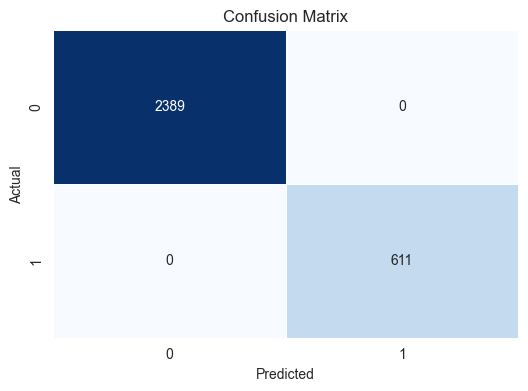

In [34]:
smote = SMOTE()
X_train,y_train = smote.fit_resample(X_train, y_train)
lr = LogisticRegression()
lr.fit(X_train, y_train)
print(lr.score(X_train, y_train))
conf_matrix = confusion_matrix(y_test, y_test)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', linewidths=.5, cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

0.9321851453175457
accuracy score: 0.7533333333333333
precision score: 0.4269535673839185
recall score: 0.6170212765957447


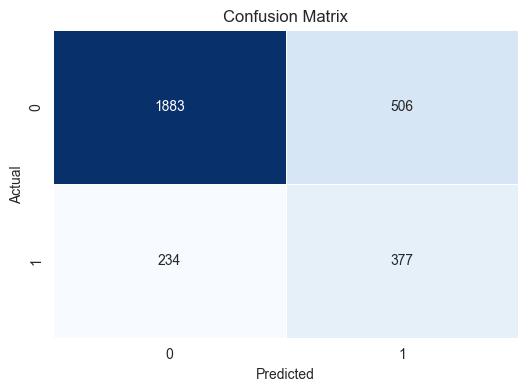

In [39]:
#KNN
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
print(knn.score(X_train, y_train))

y_pred = knn.predict(X_test)
knn_acc = accuracy_score(y_test, y_pred)
knn_per = precision_score(y_test, y_pred)
knn_rec = recall_score(y_test, y_pred)
print(f"accuracy score: {knn_acc}")
print(f"precision score: {knn_per}")
print(f"recall score: {knn_rec}")


conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', linewidths=.5, cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

0.7123250807319699


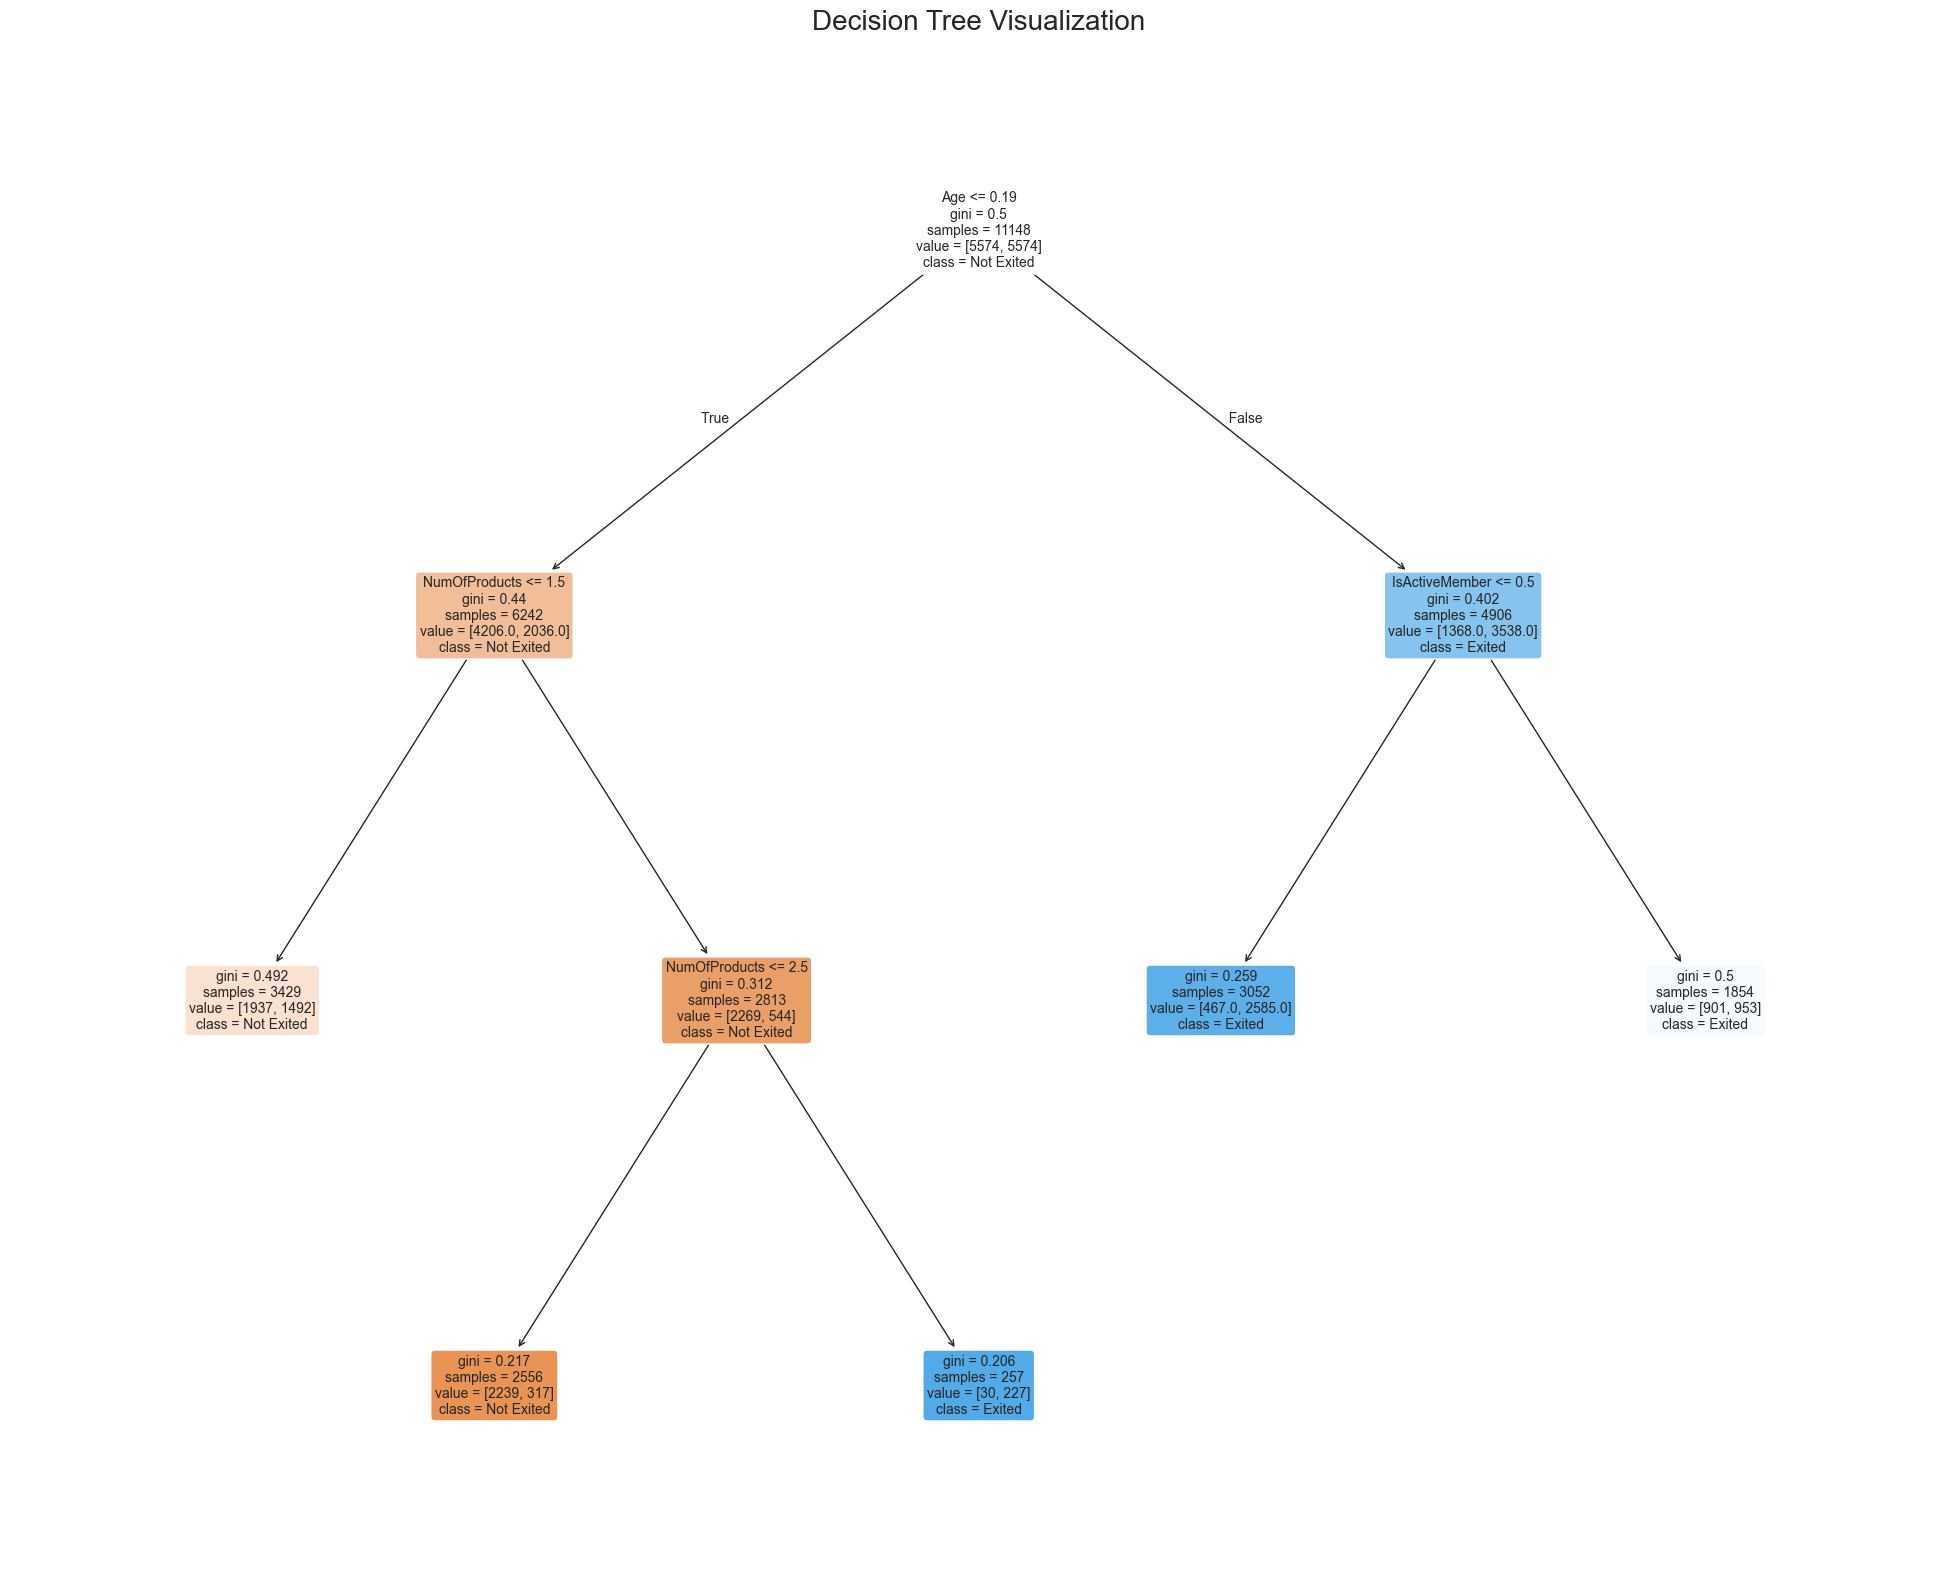

accuracy score: 0.752
precision score: 0.43435340572556763
recall score: 0.7201309328968903


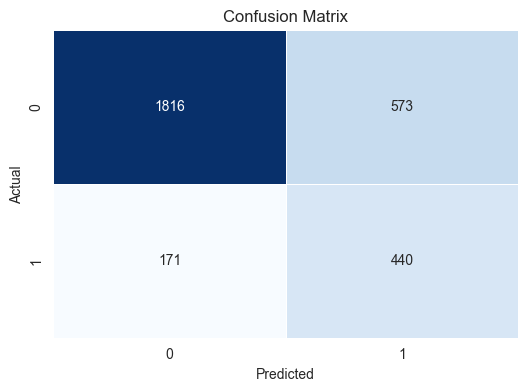

In [36]:
#DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier(max_depth=8, min_impurity_decrease=0.01, random_state=42)
clf.fit(X_train, y_train)
print(clf.score(X_train, y_train))
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(25,20))
feature_names = X_train.columns.tolist()
plot_tree(clf, filled=True, feature_names=feature_names, class_names=['Not Exited', 'Exited'], rounded=True, fontsize=10)
plt.title('Decision Tree Visualization', fontsize=20)
plt.show()


y_pred = clf.predict(X_test)
clf_acc = accuracy_score(y_test, y_pred)
clf_per = precision_score(y_test, y_pred)
clf_rec = recall_score(y_test, y_pred)

print(f"accuracy score: {clf_acc}")
print(f"precision score: {clf_per}")
print(f"recall score: {clf_rec}")



conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', linewidths=.5, cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

0.7568173663437388
accuracy score: 0.779
precision score: 0.4717391304347826
recall score: 0.7103109656301145


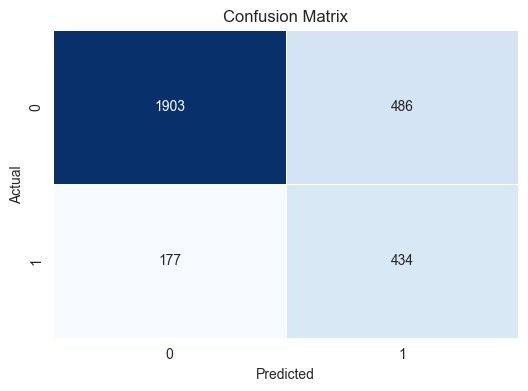

In [38]:
#RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
RF_classifier = RandomForestClassifier(n_estimators=200, min_impurity_decrease=0.01)
RF_classifier.fit(X_train, y_train)
print(RF_classifier.score(X_train, y_train))


y_pred = RF_classifier.predict(X_test)
rf_acc = accuracy_score(y_test, y_pred)
rf_per = precision_score(y_test, y_pred)
rf_rec = recall_score(y_test, y_pred)

print(f"accuracy score: {rf_acc}")
print(f"precision score: {rf_per}")
print(f"recall score: {rf_rec}")


conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', linewidths=.5, cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()